In [1]:
import sys
from pathlib import Path

# Insert repo root directory into notebook path to allow for import with the repo directory
repository_root = Path.cwd().parent.parent.resolve()
sys.path.insert(0, str(repository_root))

In [ ]:
import re
import rasterio
import numpy as np
import pandas as pd
import seaborn as sns
from rasterio.crs import CRS
import matplotlib.pyplot as plt
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from land_cover_change.config.config import resolved_config
from src.land_cover_change.utils.utils import extract_raster_map_metadata, prepare_land_cover_raster

In [4]:
geotif_dir = Path(resolved_config.dataset.raw_dataset.aoi_lulc)
geotif_dir.mkdir(parents=True, exist_ok=True)

geotif_data_path = [file for file in geotif_dir.glob("*.tif")]
geotif_data_path.reverse

# check if all metadata are thesame
geotif_metadata = []
for raster_map in geotif_data_path:
    metadata = extract_raster_map_metadata(raster_map)
    geotif_metadata.append(metadata)

reference_metadata = geotif_metadata[0]
for metadata in geotif_metadata[1:]:
    if metadata != reference_metadata:
        assert False, f"Mismatch between geotif data found"

In [6]:
for path in geotif_data_path:
    # transform .geotif files on geotif_data_path to projected coordinate system from an assumed geographic one
    output = prepare_land_cover_raster(path)

    # calculate and print out exploratory info
    land_cover = output['data']
    print(f"-----------------{path.stem}--------------------")
    print("Shape:", land_cover.shape)
    print("Total pixels:", land_cover.size)
    print("Valid pixels:", land_cover.count())
    print("Masked pixels:", np.ma.count_masked(land_cover))
    print("Are all pixels masked?", land_cover.mask.all())
    print("Valid class values:", np.unique(land_cover.compressed()))

    # Calculate the area represented per pixel in meter
    transform = output['transform']
    pixel_area_m2 = abs(transform.a * transform.e - transform.b * transform.d)
    print("Pixel area in square metres:", pixel_area_m2)
   

-----------------lulc_2025_jan_feb--------------------
Shape: (955, 1058)
Total pixels: 1010390
Valid pixels: 584929
Masked pixels: 425461
Are all pixels masked? False
Valid class values: [0 1 2 4 5 6]
Pixel area in square metres: 98.86630544456712
-----------------lulc_2020_jan_feb--------------------
Shape: (955, 1058)
Total pixels: 1010390
Valid pixels: 584929
Masked pixels: 425461
Are all pixels masked? False
Valid class values: [0 1 2 3 4 5 6 7]
Pixel area in square metres: 98.86630544456712
-----------------lulc_2016_jan_feb--------------------
Shape: (955, 1058)
Total pixels: 1010390
Valid pixels: 584929
Masked pixels: 425461
Are all pixels masked? False
Valid class values: [0 1 2 3 4 5 6 7]
Pixel area in square metres: 98.86630544456712


In [7]:
# Create a Dataframe class land area for each year
classes = resolved_config.dynamic_world_classes    # instantiate dynamic world classes
tables = []

for geotif_path in geotif_data_path:
    reprojected_lulc_map = prepare_land_cover_raster(geotif_path)
    valid_pixels = reprojected_lulc_map['data'].compressed()
    
    transform = reprojected_lulc_map['transform']
    pixel_area_m2 = abs(transform.a * transform.e - transform.b * transform.d)

    class_values, pixel_counts = np.unique(
        valid_pixels,
        return_counts=True,
    )

    area_km2 = (pixel_counts * pixel_area_m2 / 1_000_000)
    total_pixel = pixel_counts.sum() # Total pixel count of all classes
    pixel_percentage_per_class = pixel_counts / total_pixel * 100

    # Extract year from file name
    filename = geotif_path.stem
    year_match = re.search(r"(?:19|20)\d{2}", filename)

    if year_match is None:
        raise ValueError(f"No year found in file name: {filename}")

    year = int(year_match.group())
    area_table = pd.DataFrame({
        "year": year,
        "class_value": class_values,
        "pixel_count": pixel_counts,
        "area_km2": area_km2,
        "class_percentage (%)": pixel_percentage_per_class,
        "pixel_areas_km2": pixel_area_m2
    })

    tables.append(area_table)

# combine all dataframes in tables into one
df = pd.concat(tables, ignore_index=True)

# sort dataframe by year and class_value
df = df.sort_values(
    ["year", "class_value"]
).reset_index(drop=True)

# add class name to dataframe
df["class_name"] = df["class_value"].map(classes)

In [8]:
df

,year,class_value,pixel_count,area_km2,class_percentage (%),pixel_areas_km2,class_name
0,2016,0,738,0.072963,0.126169,98.866305,water
1,2016,1,314187,31.062508,53.713699,98.866305,trees
2,2016,2,782,0.077313,0.133691,98.866305,grass
3,2016,3,446,0.044094,0.076249,98.866305,flooded vegetation
4,2016,4,3482,0.344252,0.595286,98.866305,crops
5,2016,5,39191,3.874669,6.700129,98.866305,shrub and scrub
6,2016,6,224005,22.146547,38.296101,98.866305,built area
7,2016,7,2098,0.207422,0.358676,98.866305,bare ground
8,2020,0,322,0.031835,0.055049,98.866305,water
9,2020,1,251994,24.913716,43.081126,98.866305,trees


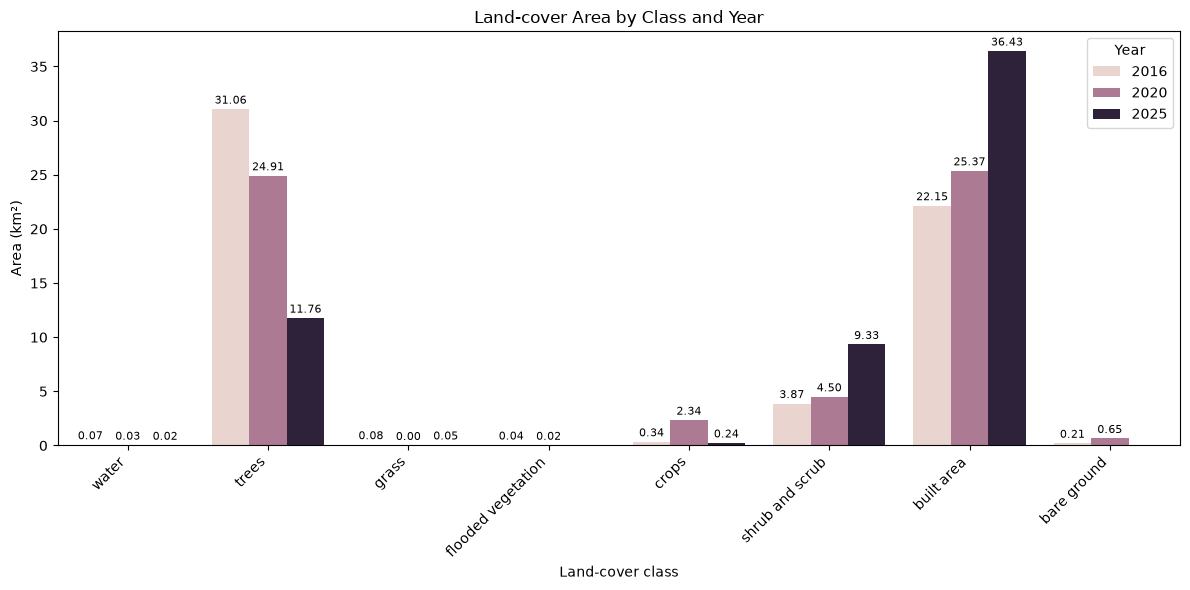

In [9]:
# Visualise DataFrame on a multiple bar chart

# set plot figure size
fig, ax = plt.subplots(figsize=(12, 6))

# plot a multiple bar chart
sns.barplot(
    data=df,
    x="class_name",
    y="area_km2",
    hue="year",
    ax=ax
)

# annotate the bars
for container in ax.containers:
    ax.bar_label(
        container, #type: ignore
        fmt="%.2f",
        padding=2,
        fontsize=8,
    )

# set x and y axis label, and also plot title
ax.set(
    xlabel="Land-cover class", 
    ylabel="Area (km²)",
    title="Land-cover Area by Class and Year"
)

# show plot
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [10]:
# create a comparison dataFrame based on years
area_comparison = df.pivot(
    index="class_name",
    columns="year",
    values=["area_km2", "class_percentage (%)"]
).fillna(0)

# Name the index and both column levels
area_comparison = area_comparison.rename_axis(
    index="Land-cover class",
    columns=["Measurement", "Year"],
)

# Select only the area columns.
area_subset = pd.IndexSlice[:, pd.IndexSlice["area_km2", :],]               #type: ignore
area_max = area_comparison["area_km2"].to_numpy().max()

# Select only the percentage columns.
percentage_subset = pd.IndexSlice[:, pd.IndexSlice["class_percentage (%)", :],]           #type: ignore
percentage_max = area_comparison["class_percentage (%)"].to_numpy().max()

# Apply different formatting to each measurement.
formatters = {
    column: (
        "{:.4f}"
        if column[0] == "area_km2"
        else "{:.2f}%"
    )
    for column in area_comparison.columns              #type: ignore
}

# visualise area_comparison
visual_table = (
    area_comparison
    .style
    .format(formatters)

    # Compare area values only with other area values.
    .background_gradient(
        cmap="Greens",
        axis=0,
        subset=area_subset,
        vmin=0,
        vmax=area_max
    )

    # Compare percentage values only with other percentages.
    .background_gradient(
        cmap="Blues",
        axis=0,
        subset=percentage_subset,
        vmin=0,
        vmax=percentage_max
    )

    .set_caption(
        "Land-cover Area and Percentage by Class and Year"
    )
    .set_table_attributes(
        'style="width: 70%; table-layout: fixed;"'
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("min-width", "80px"),
                ("padding", "9px"),
                ("font-size", "13px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "9px"),
                ("font-size", "12px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("padding", "12px"),
            ],
        },
    ])
)

display(visual_table)

In [11]:
# select area_km2 column
area_by_year = area_comparison["area_km2"]
# create a sorted list of year. This will be used to ensure chronological calculation and comparism
years = sorted(area_by_year.columns)

percentage_change = pd.DataFrame(index=area_by_year.index)

for earlier_year, later_year in zip(years[:-1], years[1:]):
    earlier_area = area_by_year[earlier_year]
    later_area = area_by_year[later_year]

    percentage_change[f"{earlier_year}–{later_year}"] = np.where(
        earlier_area != 0,
        ((later_area - earlier_area) / earlier_area) * 100,
        np.nan,
    )

# calculcate net percentage change between 2016 to 2025
if 2016 in area_by_year.columns and 2025 in area_by_year.columns:
    percentage_change["2016–2025"] = np.where(
        area_by_year[2016] != 0,
        ((area_by_year[2025] - area_by_year[2016]) / area_by_year[2016]) * 100,
        np.nan,
    )

In [12]:
percentage_change_table = (
    percentage_change
    .rename_axis(
        index="Land-cover class",
        columns="Period",
    )
    .style
    .format("{:+.2f}%")
    .bar(
        align="zero",
        color=["#d65f5f", "#5fba7d"],
    )
    .set_caption(
        "Percentage Change in Land-cover Area"
    )
    .set_table_attributes(
        'style="width: 100%; table-layout: fixed;"'
    )
)

display(percentage_change_table)

Period,2016–2020,2020–2025,2016–2025
Land-cover class,,,
bare ground,+213.68%,-100.00%,-100.00%
built area,+14.54%,+43.60%,+64.48%
crops,+579.72%,-89.91%,-31.39%
flooded vegetation,-51.57%,-100.00%,-100.00%
grass,-93.99%,+1036.17%,-31.71%
shrub and scrub,+16.16%,+107.23%,+140.72%
trees,-19.79%,-52.78%,-62.13%
water,-56.37%,-27.95%,-68.56%


In [13]:
raster_2016 = prepare_land_cover_raster(
    geotif_dir / "lulc_2016_jan_feb.tif"
)
raster_2020 = prepare_land_cover_raster(
    geotif_dir / "lulc_2020_jan_feb.tif"
)

values_2016 = raster_2016["data"]
values_2020 = raster_2020["data"]

if values_2016.shape != values_2020.shape:
    raise ValueError("The rasters must have the same shape and alignment.")

mask_2016 = np.ma.getmaskarray(values_2016)
mask_2020 = np.ma.getmaskarray(values_2020)
common_valid_mask = ~(mask_2016 | mask_2020)

classes_2016 = np.ma.getdata(values_2016)[common_valid_mask]
classes_2020 = np.ma.getdata(values_2020)[common_valid_mask]

class_values = list(range(9))

transition_counts = pd.crosstab(
    pd.Categorical(classes_2016, categories=class_values),
    pd.Categorical(classes_2020, categories=class_values),
    rownames=["from class (2016)"],
    colnames=["to class (2020)"],
    dropna=False,
)

transition_counts = transition_counts.rename(
    index=resolved_config.dynamic_world_classes,
    columns=resolved_config.dynamic_world_classes,
)
transition_counts
# row from (2016), column to (2020)

to class (2020),water,trees,grass,flooded vegetation,crops,shrub and scrub,built area,bare ground,snow and ice
from class (2016),,,,,,,,,
water,264,294,1,86,5,49,39,0,0
trees,52,232495,0,59,13260,32148,34368,1805,0
grass,0,503,46,0,0,233,0,0,0
flooded vegetation,0,97,0,52,36,24,237,0,0
crops,0,724,0,0,1189,395,1076,98,0
shrub and scrub,0,14266,0,19,4478,9518,9572,1338,0
built area,6,3540,0,0,4540,3111,209468,3340,0
bare ground,0,75,0,0,160,47,1816,0,0
snow and ice,0,0,0,0,0,0,0,0,0


In [14]:
transform = raster_2016["transform"]

pixel_area_km2 = abs(
    transform.a * transform.e
    - transform.b * transform.d
) / 1_000_000

transition_area_km2 = (
    transition_counts * pixel_area_km2
)

# # row from (2016), column to (2020)
transition_area_km2

to class (2020),water,trees,grass,flooded vegetation,crops,shrub and scrub,built area,bare ground,snow and ice
from class (2016),,,,,,,,,
water,0.026101,0.029067,0.000099,0.008503,0.000494,0.004844,0.003856,0.000000,0.0
trees,0.005141,22.985922,0.000000,0.005833,1.310967,3.178354,3.397837,0.178454,0.0
grass,0.000000,0.049730,0.004548,0.000000,0.000000,0.023036,0.000000,0.000000,0.0
flooded vegetation,0.000000,0.009590,0.000000,0.005141,0.003559,0.002373,0.023431,0.000000,0.0
crops,0.000000,0.071579,0.000000,0.000000,0.117552,0.039052,0.106380,0.009689,0.0
shrub and scrub,0.000000,1.410427,0.000000,0.001878,0.442723,0.941009,0.946348,0.132283,0.0
built area,0.000593,0.349987,0.000000,0.000000,0.448853,0.307573,20.709327,0.330213,0.0
bare ground,0.000000,0.007415,0.000000,0.000000,0.015819,0.004647,0.179541,0.000000,0.0
snow and ice,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [15]:
transition_percentage = (
    transition_counts
    .div(
        transition_counts.sum(axis=1).replace(0, np.nan),
        axis=0,
    )
    * 100
)

transition_percentage

to class (2020),water,trees,grass,flooded vegetation,crops,shrub and scrub,built area,bare ground,snow and ice
from class (2016),,,,,,,,,
water,35.772358,39.837398,0.135501,11.653117,0.677507,6.639566,5.284553,0.000000,0.0
trees,0.016551,73.998924,0.000000,0.018779,4.220417,10.232123,10.938708,0.574499,0.0
grass,0.000000,64.322251,5.882353,0.000000,0.000000,29.795396,0.000000,0.000000,0.0
flooded vegetation,0.000000,21.748879,0.000000,11.659193,8.071749,5.381166,53.139013,0.000000,0.0
crops,0.000000,20.792648,0.000000,0.000000,34.147042,11.344055,30.901781,2.814474,0.0
shrub and scrub,0.000000,36.401215,0.000000,0.048481,11.426093,24.286188,24.423975,3.414049,0.0
built area,0.002679,1.580322,0.000000,0.000000,2.026740,1.388808,93.510413,1.491038,0.0
bare ground,0.000000,3.574833,0.000000,0.000000,7.626311,2.240229,86.558627,0.000000,0.0
snow and ice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
persistence = pd.Series(
    np.diag(transition_area_km2),
    index=transition_area_km2.index,
)

earlier_area = transition_area_km2.sum(axis=1)

later_area = (
    transition_area_km2
    .sum(axis=0)
    .reindex(transition_area_km2.index)
)

loss = earlier_area - persistence
gain = later_area - persistence

transition_summary = pd.DataFrame({
    "earlier_area_km2": earlier_area,
    "later_area_km2": later_area,
    "persistence_km2": persistence,
    "gain_km2": gain,
    "loss_km2": loss,
})

transition_summary["net_change_km2"] = (
    transition_summary["gain_km2"]
    - transition_summary["loss_km2"]
)

transition_summary["total_change_km2"] = (
    transition_summary["gain_km2"]
    + transition_summary["loss_km2"]
)

In [17]:
transition_summary

,earlier_area_km2,later_area_km2,persistence_km2,gain_km2,loss_km2,net_change_km2,total_change_km2
from class (2016),,,,,,,
water,0.072963,0.031835,0.026101,0.005734,0.046863,-0.041128,0.052597
trees,31.062508,24.913716,22.985922,1.927794,8.076586,-6.148792,10.004380
grass,0.077313,0.004647,0.004548,0.000099,0.072766,-0.072667,0.072864
flooded vegetation,0.044094,0.021355,0.005141,0.016214,0.038953,-0.022739,0.055167
crops,0.344252,2.339968,0.117552,2.222416,0.226700,1.995715,2.449116
shrub and scrub,3.874669,4.500889,0.941009,3.559879,2.933660,0.626219,6.493539
built area,22.146547,25.366721,20.709327,4.657394,1.437219,3.220174,6.094613
bare ground,0.207422,0.650639,0.000000,0.650639,0.207422,0.443218,0.858061
snow and ice,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
